In [1]:
import pandas as pd
import glob

In [2]:
files_paths = glob.glob('../data_files/*.csv')

In [3]:
colunas = ['id', 'clube', 'plantel', 'idade_media', 'estrangeiros', 'vlr_mercado_medio', 'vlr_mercado_total', 'ano']
dataframes = []
for path in files_paths:

    df = pd.read_csv(path)
    df.columns = colunas
    df.drop('id', axis =1, inplace=True)
    df = df.iloc[1:, :]
    dataframes.append(df)

In [4]:
df_final = pd.concat(dataframes)

In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544 entries, 1 to 20
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   clube              544 non-null    object
 1   plantel            544 non-null    int64 
 2   idade_media        544 non-null    object
 3   estrangeiros       544 non-null    int64 
 4   vlr_mercado_medio  544 non-null    object
 5   vlr_mercado_total  544 non-null    object
 6   ano                544 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 34.0+ KB


In [6]:
def format_value(vlr):
    if 'mi.' in vlr:
        vlr = float(vlr.replace("mi.", "").replace("€", "").replace(" ", "").replace(",", "."))
        vlr = vlr*1000000

    elif 'mil' in vlr:
        vlr = float(vlr.replace("mil", "").replace("€", "").replace(" ", "").replace(",", "."))
        vlr = vlr*1000
    elif '-' in vlr:
        #print(vlr)
        vlr = 0

    return vlr


In [7]:
df_final['vlr_mercado_medio_format'] = df_final['vlr_mercado_medio'].apply(format_value)
df_final['vlr_mercado_total_format'] = df_final['vlr_mercado_total'].apply(format_value)

In [8]:
df_final['vlr_mercado_medio_format'] = df_final['vlr_mercado_medio_format'].astype('float')
df_final['vlr_mercado_total_format'] = df_final['vlr_mercado_total_format'].astype('float')

In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544 entries, 1 to 20
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   clube                     544 non-null    object 
 1   plantel                   544 non-null    int64  
 2   idade_media               544 non-null    object 
 3   estrangeiros              544 non-null    int64  
 4   vlr_mercado_medio         544 non-null    object 
 5   vlr_mercado_total         544 non-null    object 
 6   ano                       544 non-null    int64  
 7   vlr_mercado_medio_format  544 non-null    float64
 8   vlr_mercado_total_format  544 non-null    float64
dtypes: float64(2), int64(3), object(4)
memory usage: 42.5+ KB


In [10]:
df_final[['vlr_mercado_medio_format', 'vlr_mercado_total_format']].describe()

,vlr_mercado_medio_format,vlr_mercado_total_format
count,5.440000e+02,5.440000e+02
mean,8.047206e+05,3.857199e+07
std,1.011678e+06,4.188516e+07
min,0.000000e+00,0.000000e+00
25%,4.750000e+04,2.195000e+06
50%,4.785000e+05,2.679000e+07
75%,1.172500e+06,6.080000e+07
max,7.700000e+06,2.387500e+08


In [11]:
df_final.reset_index(inplace=True)

In [12]:
df_final.columns = ['posicao_campeonato', 'clube', 'plantel', 'idade_media', 'estrangeiros',
       'vlr_mercado_medio', 'vlr_mercado_total', 'ano',
       'vlr_mercado_medio_format', 'vlr_mercado_total_format']

In [13]:
df_final.loc[df_final['vlr_mercado_medio_format'].idxmax(), ::]

posicao_campeonato                     1
clube                       SE Palmeiras
plantel                               31
idade_media                         25,9
estrangeiros                           8
vlr_mercado_medio             7,70 mi. €
vlr_mercado_total           238,75 mi. €
ano                                 2024
vlr_mercado_medio_format       7700000.0
vlr_mercado_total_format     238750000.0
Name: 504, dtype: object

In [14]:
df_final.sort_values("vlr_mercado_total", ascending= False)

,posicao_campeonato,clube,plantel,idade_media,estrangeiros,vlr_mercado_medio,vlr_mercado_total,ano,vlr_mercado_medio_format,vlr_mercado_total_format
469,6,Grêmio FBPA,62,"23,5",10,"1,61 mi. €","99,98 mi. €",2022,1610000.0,99980000.0
470,7,SC Corinthians,48,"23,2",8,"2,08 mi. €","99,95 mi. €",2022,2080000.0,99950000.0
245,2,CR Flamengo,61,"23,5",7,"1,63 mi. €","99,15 mi. €",2011,1630000.0,99150000.0
246,3,São Paulo FC,52,"22,9",5,"1,91 mi. €","99,08 mi. €",2011,1910000.0,99080000.0
493,10,Fluminense FC,67,"24,7",9,"1,48 mi. €","98,95 mi. €",2023,1480000.0,98950000.0
...,...,...,...,...,...,...,...,...,...,...
87,10,Paysandu SC,36,"25,5",1,-,-,2003,0.0,0.0
88,11,São Paulo FC,38,"22,7",2,-,-,2003,0.0,0.0
89,12,CR Flamengo,47,"22,4",1,-,-,2003,0.0,0.0
90,13,Goiás EC,31,"23,5",1,-,-,2003,0.0,0.0


In [15]:
idx =df_final.groupby(['ano'])['vlr_mercado_total_format'].idxmax()

dfgrp_ano_max = df_final.loc[idx]
dfgrp_ano_max = dfgrp_ano_max[dfgrp_ano_max['ano']>2004]

In [16]:
dfgrp_ano_max['clube'].value_counts()

clube
São Paulo FC        6
CR Flamengo         6
SE Palmeiras        4
SC Corinthians      3
Fluminense FC       1
Atlético Mineiro    1
Name: count, dtype: int64

In [17]:
dfgrp_ano_max

,posicao_campeonato,clube,plantel,idade_media,estrangeiros,vlr_mercado_medio,vlr_mercado_total,ano,vlr_mercado_medio_format,vlr_mercado_total_format
124,1,SC Corinthians,43,"22,5",4,"1,38 mi. €","59,30 mi. €",2005,1380000.0,59300000.0
144,1,SC Corinthians,61,"23,3",2,411 mil €,"25,05 mi. €",2006,411000.0,25050000.0
164,1,São Paulo FC,56,"22,9",1,"1,20 mi. €","67,40 mi. €",2007,1200000.0,67400000.0
184,1,Fluminense FC,49,"23,0",4,"1,17 mi. €","57,30 mi. €",2008,1170000.0,57300000.0
204,1,CR Flamengo,56,"24,0",6,"1,80 mi. €","100,80 mi. €",2009,1800000.0,100800000.0
224,1,São Paulo FC,56,"22,9",3,"1,96 mi. €","109,55 mi. €",2010,1960000.0,109550000.0
244,1,Atlético Mineiro,52,"24,8",2,"2,12 mi. €","110,00 mi. €",2011,2120000.0,110000000.0
264,1,São Paulo FC,56,"23,1",4,"2,01 mi. €","112,80 mi. €",2012,2010000.0,112800000.0
284,1,São Paulo FC,45,"24,8",6,"3,33 mi. €","149,65 mi. €",2013,3330000.0,149650000.0
304,1,São Paulo FC,49,"24,1",5,"1,86 mi. €","91,15 mi. €",2014,1860000.0,91150000.0


In [18]:
df_final['ano'] = df_final['ano']+1

In [19]:
df_final = df_final[df_final['ano']<2026]

In [20]:
idx =df_final.groupby(['ano'])['vlr_mercado_total_format'].idxmax()

dfgrp_ano_max = df_final.loc[idx]
dfgrp_ano_max = dfgrp_ano_max[dfgrp_ano_max['ano']>2005]

dfgrp_ano_max

,posicao_campeonato,clube,plantel,idade_media,estrangeiros,vlr_mercado_medio,vlr_mercado_total,ano,vlr_mercado_medio_format,vlr_mercado_total_format
124,1,SC Corinthians,43,"22,5",4,"1,38 mi. €","59,30 mi. €",2006,1380000.0,59300000.0
144,1,SC Corinthians,61,"23,3",2,411 mil €,"25,05 mi. €",2007,411000.0,25050000.0
164,1,São Paulo FC,56,"22,9",1,"1,20 mi. €","67,40 mi. €",2008,1200000.0,67400000.0
184,1,Fluminense FC,49,"23,0",4,"1,17 mi. €","57,30 mi. €",2009,1170000.0,57300000.0
204,1,CR Flamengo,56,"24,0",6,"1,80 mi. €","100,80 mi. €",2010,1800000.0,100800000.0
224,1,São Paulo FC,56,"22,9",3,"1,96 mi. €","109,55 mi. €",2011,1960000.0,109550000.0
244,1,Atlético Mineiro,52,"24,8",2,"2,12 mi. €","110,00 mi. €",2012,2120000.0,110000000.0
264,1,São Paulo FC,56,"23,1",4,"2,01 mi. €","112,80 mi. €",2013,2010000.0,112800000.0
284,1,São Paulo FC,45,"24,8",6,"3,33 mi. €","149,65 mi. €",2014,3330000.0,149650000.0
304,1,São Paulo FC,49,"24,1",5,"1,86 mi. €","91,15 mi. €",2015,1860000.0,91150000.0


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
dfgrp_ano_max.sort_values('vlr_mercado_total_format', ascending=False, inplace = True)

In [23]:
dfgrp_ano_max['clube'].drop_duplicates()

504        SE Palmeiras
484         CR Flamengo
284        São Paulo FC
404      SC Corinthians
244    Atlético Mineiro
184       Fluminense FC
Name: clube, dtype: object

In [56]:
colors = {"SE Palmeiras":"green",
          "CR Flamengo":"darkred",
          "São Paulo FC":"red",
          "SC Corinthians": "black",
          "Atlético Mineiro": "dimgray",
          "Fluminense FC":"firebrick"}

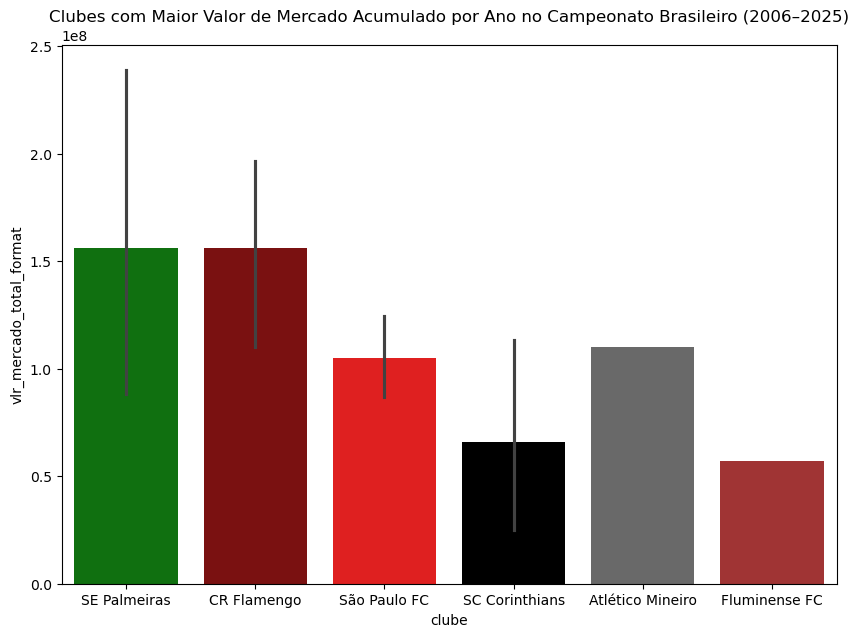

In [57]:
plt.figure(figsize = (10, 7))

sns.barplot(dfgrp_ano_max, x = 'clube', y = 'vlr_mercado_total_format', hue= "clube", palette=colors)
plt.title("Clubes com Maior Valor de Mercado Acumulado por Ano no Campeonato Brasileiro (2006–2025)")
plt.show()

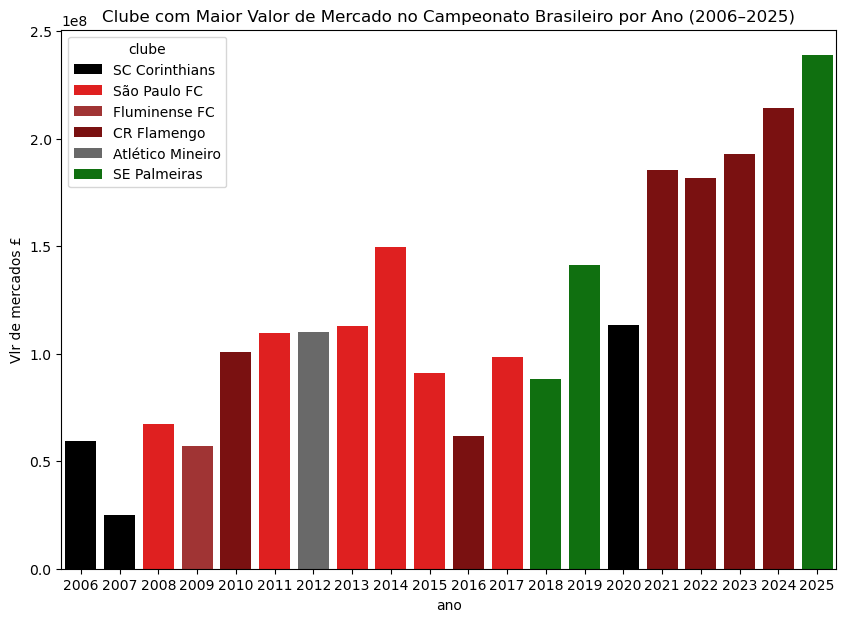

In [58]:
plt.figure(figsize = (10, 7))

sns.barplot(dfgrp_ano_max, x = 'ano', y = 'vlr_mercado_total_format', hue= "clube", palette=colors)
plt.ylabel("Vlr de mercados £")
plt.title("Clube com Maior Valor de Mercado no Campeonato Brasileiro por Ano (2006–2025)")
plt.show()

In [59]:
clubes = dfgrp_ano_max['clube'].drop_duplicates().values.tolist()

In [60]:
clube = ["CR Flamengo"]

dffilter = df_final[df_final['clube'].isin(clubes)]

In [61]:
def plot_line_clubes(df, clubes):
    for clube in clubes:

        plt.figure(figsize=(15, 4))
        sns.lineplot(data = df[df['clube'] != clube], x = 'ano', y = 'vlr_mercado_total_format', hue = 'clube', palette = colors, alpha = .3)
        sns.lineplot(data = df[df['clube'] == clube], x = 'ano', y = 'vlr_mercado_total_format', hue = 'clube', palette = colors, marker='o')

        max_y = df[df['clube'] == clube].sort_values('ano').tail(1)['vlr_mercado_total_format'].values[0]
        plt.annotate(clube, (2025.2, max_y))
        
        plt.title("Evolução da série histórica(2006 - 2025) do valor de mercado - {clube}".format(clube = clube))
        plt.show()

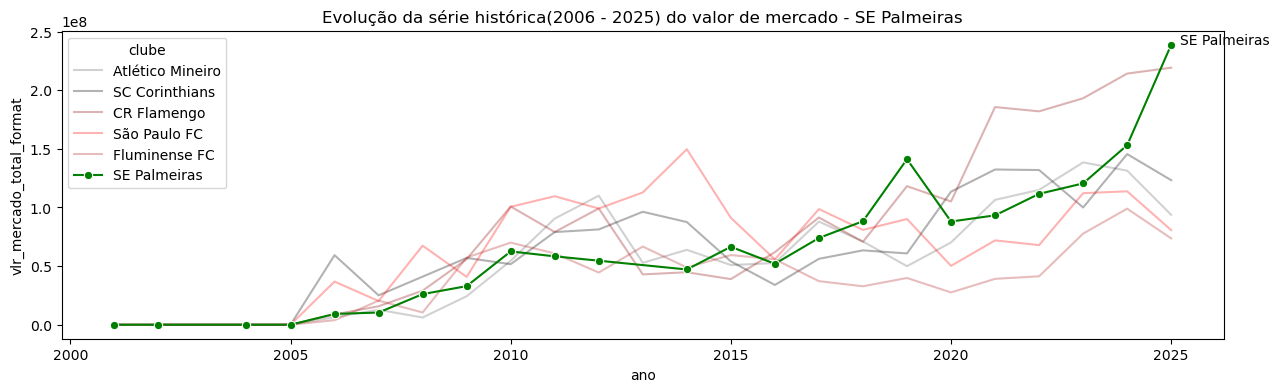

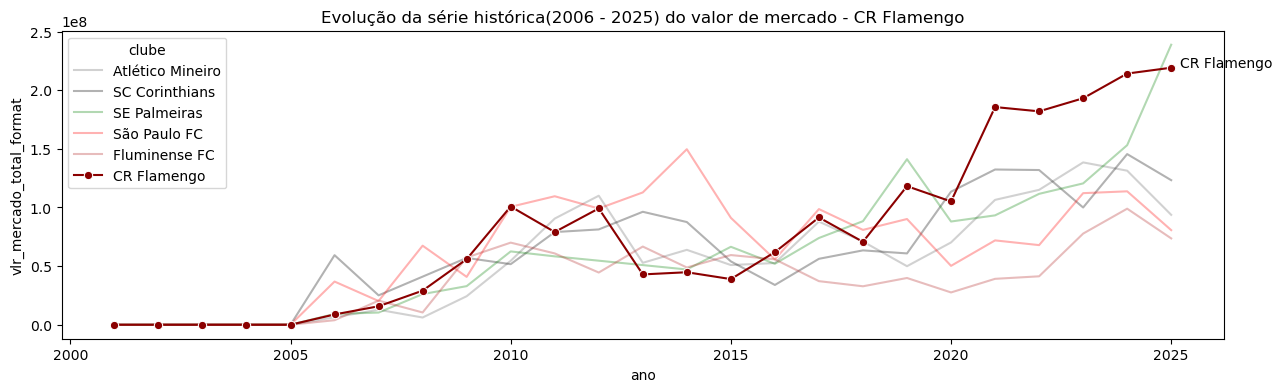

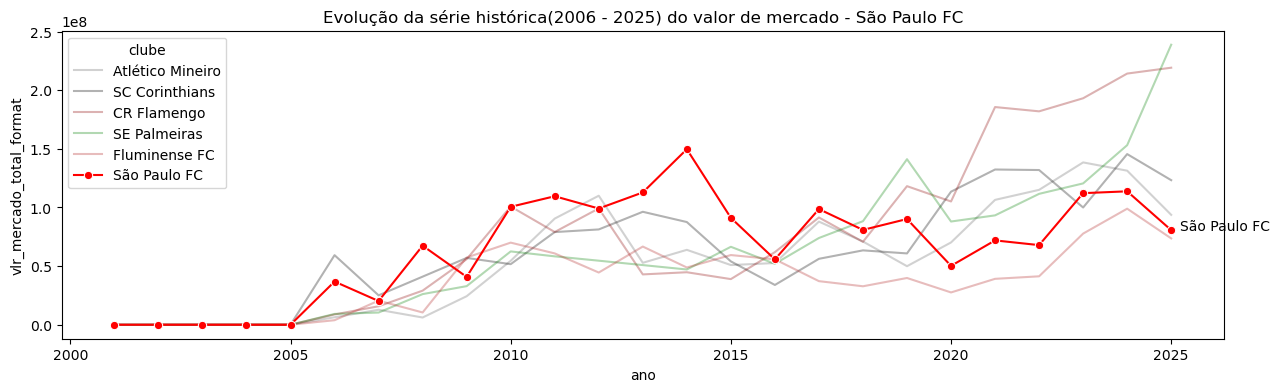

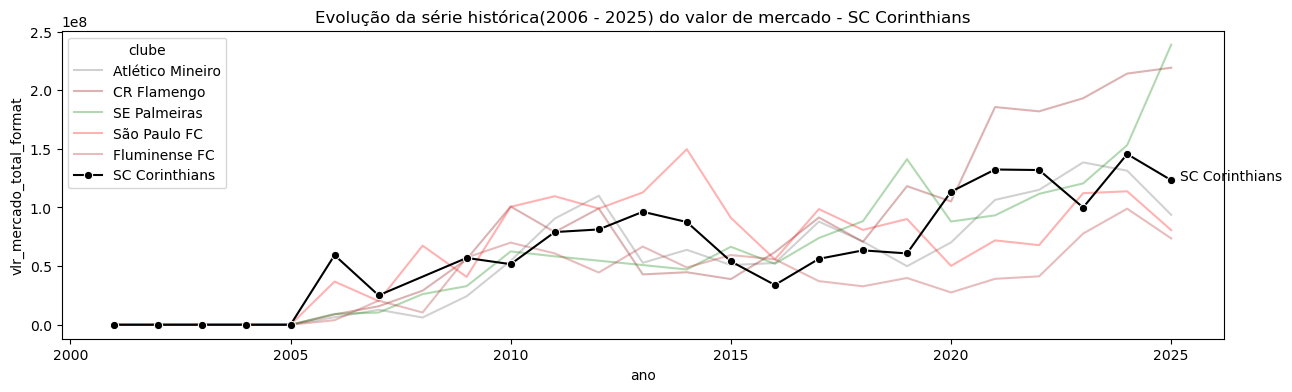

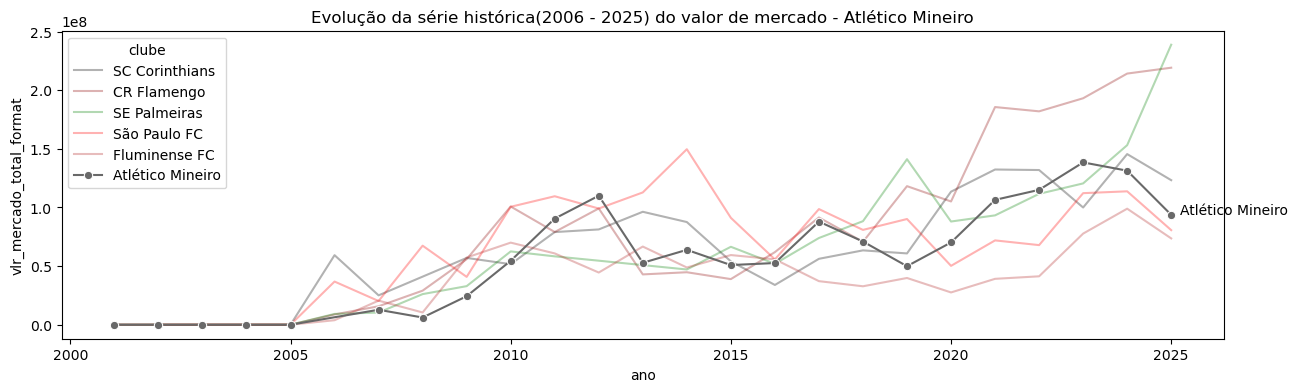

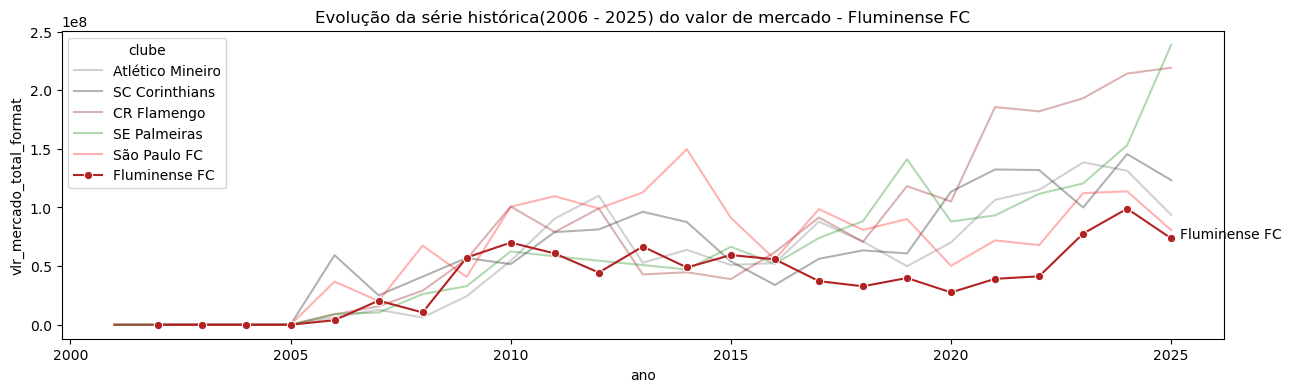

In [62]:
plot_line_clubes(dffilter, clubes)